In [45]:
import numpy as np
import seaborn as sns
from scipy import stats

In [20]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### 分布の描画

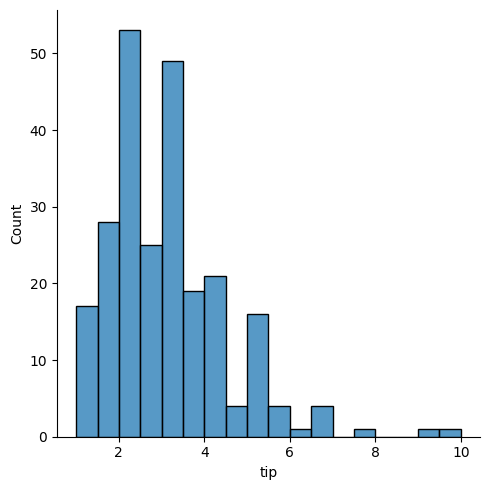

In [21]:
sns.displot(df['tip'], kde=False)

In [22]:
sns.__version__

'0.13.2'

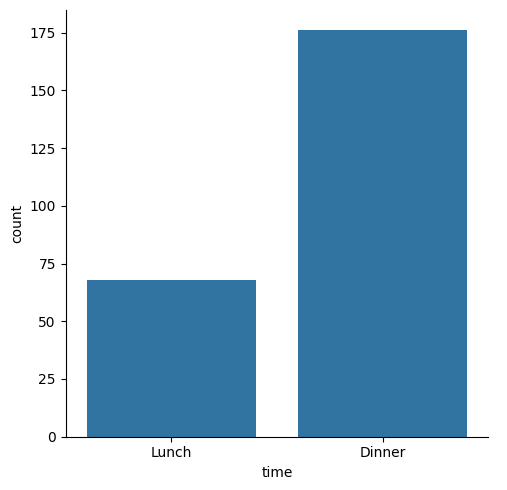

In [23]:
sns.catplot(x='time', data=df, kind='count')

### 記述統計と推測統計

#### 代表値と平均値

In [24]:
df
df['tip_rate'] = df['tip'] / df['total_bill']
df

,total_bill,tip,sex,smoker,day,time,size,tip_rate
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.203927
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0.073584
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.088222
242,17.82,1.75,Male,No,Sat,Dinner,2,0.098204


In [25]:
np.mean(df['tip'])

2.99827868852459

In [26]:
df['tip_rate'].mean()

0.16080258172250472

In [27]:
df.groupby('sex')['tip_rate'].mean()

/tmp/ipykernel_26/3348616537.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')['tip_rate'].mean()


sex
Male      0.157651
Female    0.166491
Name: tip_rate, dtype: float64

/tmp/ipykernel_26/3836395875.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='sex', y='tip_rate', data=df, ci=None)


<Axes: xlabel='sex', ylabel='tip_rate'>

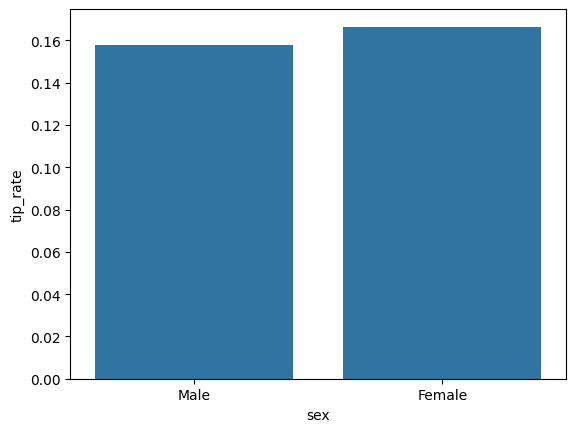

In [28]:
sns.barplot(x='sex', y='tip_rate', data=df, ci=None)

#### 中央値

In [29]:
np.median([1,3,5])

3.0

In [30]:
df['tip_rate']

0      0.059447
1      0.160542
2      0.166587
3      0.139780
4      0.146808
         ...   
239    0.203927
240    0.073584
241    0.088222
242    0.098204
243    0.159744
Name: tip_rate, Length: 244, dtype: float64

In [31]:
np.median(df['tip_rate'])

0.15476977125802577

In [32]:
#### なぜ平均値と中央値にズレがあるのか? → 外れ値が原因

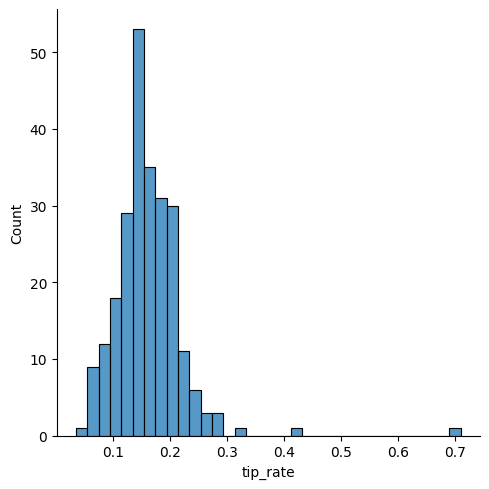

In [33]:
sns.displot(df['tip_rate'])

In [34]:
df['tip_rate'].median()

0.15476977125802577

In [37]:
df.groupby('sex', observed=True)[['tip', 'tip_rate', 'total_bill', 'size']].median()

,tip,tip_rate,total_bill,size
sex,,,,
Male,3.00,0.153492,18.35,2.0
Female,2.75,0.155581,16.40,2.0


/tmp/ipykernel_26/1493937193.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='sex',y='tip_rate', data=df, estimator=np.median, ci=None)


<Axes: xlabel='sex', ylabel='tip_rate'>

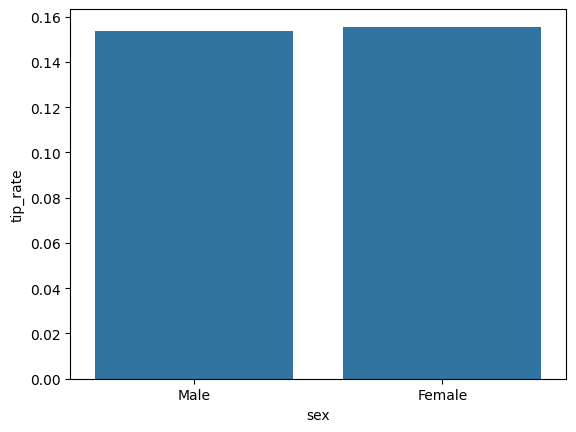

In [40]:
sns.barplot(x='sex',y='tip_rate', data=df, estimator=np.median, ci=None)

In [42]:
df.sort_values('tip_rate', ascending=True)

,total_bill,tip,sex,smoker,day,time,size,tip_rate
237,32.83,1.17,Male,Yes,Sat,Dinner,2,0.035638
102,44.30,2.50,Female,Yes,Sat,Dinner,3,0.056433
57,26.41,1.50,Female,No,Sat,Dinner,2,0.056797
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
187,30.46,2.00,Male,Yes,Sun,Dinner,5,0.065660
...,...,...,...,...,...,...,...,...
183,23.17,6.50,Male,Yes,Sun,Dinner,4,0.280535
232,11.61,3.39,Male,No,Sat,Dinner,2,0.291990
67,3.07,1.00,Female,Yes,Sat,Dinner,1,0.325733
178,9.60,4.00,Female,Yes,Sun,Dinner,2,0.416667


#### 最頻値(mode)
中央値や平均値ほど使わないけど重要

unimodal, bimodal multimodalがある

stats.mode()
df['columns'].mode()

In [46]:
stats.mode([1,2,3,4,5,2,2])

ModeResult(mode=2, count=3)

In [49]:
mode, count = stats.mode([1,2,3,4,5,2,2])
print(mode,count)

2 3


In [53]:
#### なぜリストで返ってきている??
mode, count = stats.mode(df['tip_rate'])
print(mode,count)

0.1448225923244026 2


#### 散布度
データのばらつき

散布度を表す指標
範囲、四分位数、平均偏差、分散、標準偏差

#### 範囲
最大値 - 最小値
外れ値に弱い
全体のばらつき度を示すには不十分

In [54]:
np.min(df['tip'])

1.0

In [55]:
df['tip'].min()

1.0

In [57]:
df.groupby('sex')['tip'].min()

/tmp/ipykernel_26/3668012932.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')['tip'].min()


sex
Male      1.0
Female    1.0
Name: tip, dtype: float64

#### 四分位数
- データをならべて四分かつした時の25%,50%, 75%の値
- 範囲よりも外れ値に強い
- 全体のばらつき度を示すにはまだ不十分
  